In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from diffusers import StableDiffusionXLPipeline, AutoencoderKL, DPMSolverMultistepScheduler,EulerDiscreteScheduler

device = "cuda"
torch.manual_seed(42)

# =========================================================
# fp16 fixed vae + pipeline
# =========================================================
vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    vae=vae, torch_dtype=torch.float16, use_safetensors=True)

# Use DPM-Solver (same as npnet_pipeline.py)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

# =========================================================
# 5 prompts — diverse categories
# =========================================================
PROMPTS = [
    "a golden retriever playing in a field of sunflowers, sunny day, 4k",
    "a steaming cup of coffee on a wooden table, morning light, bokeh",
    "a neon-lit cyberpunk street at night, rain, reflections, cinematic",
    "a watercolor painting of a cherry blossom tree by a lake, soft colors",
    "a vintage red car parked on a coastal road, ocean view, golden hour",
]

NEGATIVE = "blurry, low quality, distorted, ugly, bad anatomy"
NUM_STEPS = 30
GUIDANCE  = 7.5
CAPTURE_STEPS = [0, 6, 12, 18, 24, 29]

2026-06-23 23:56:09.848939: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 23:56:09.873201: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [2]:
# =========================================================
# Denoising loop — capture x0 at CAPTURE_STEPS
# =========================================================
all_x0 = {}

for pi, prompt in enumerate(PROMPTS):
    print(f"\n{'='*60}")
    print(f"Prompt {pi+1}/{len(PROMPTS)}: {prompt}")
    print(f"{'='*60}")

    # --- encode prompt ---
    with torch.no_grad():
        (prompt_embeds, neg_embeds, pooled_embeds, neg_pooled_embeds,
        ) = pipe.encode_prompt(
            prompt=prompt, negative_prompt=NEGATIVE,
            device=device, num_images_per_prompt=1,
            do_classifier_free_guidance=True)

    # --- init latent ---
    latents = torch.randn((1, 4, 128, 128), device=device, dtype=torch.float16)
    latents = latents * pipe.scheduler.init_noise_sigma

    # --- scheduler ---
    pipe.scheduler.set_timesteps(NUM_STEPS, device=device)
    timesteps = pipe.scheduler.timesteps

    # --- time ids ---
    add_time_ids = torch.tensor(
        [(1024, 1024, 0, 0, 1024, 1024)], device=device, dtype=torch.float16)
    add_time_ids = torch.cat([add_time_ids, add_time_ids], dim=0)

    # --- loop ---
    x0_images = []
    for i, t in enumerate(timesteps):
        latent_input = torch.cat([latents] * 2)
        latent_input = pipe.scheduler.scale_model_input(latent_input, t)

        with torch.no_grad():
            noise_pred = pipe.unet(
                latent_input, t,
                encoder_hidden_states=torch.cat([neg_embeds, prompt_embeds]),
                added_cond_kwargs={
                    "text_embeds": torch.cat([neg_pooled_embeds, pooled_embeds]),
                    "time_ids": add_time_ids,
                },
            ).sample

        noise_uncond, noise_cond = noise_pred.chunk(2)
        noise_pred = noise_uncond + GUIDANCE * (noise_cond - noise_uncond)

        # --- x0 prediction at selected steps ---
        if i in CAPTURE_STEPS:
            t_idx = int(t.item()) if isinstance(t, torch.Tensor) else int(t)

            alpha_t = pipe.scheduler.alphas_cumprod[t_idx].sqrt().to(
                device, dtype=latents.dtype)
            sigma_t = (1.0 - pipe.scheduler.alphas_cumprod[t_idx]).sqrt().to(
                device, dtype=latents.dtype)

            x0_pred = (latents - sigma_t * noise_pred) / alpha_t

            with torch.no_grad(), torch.autocast("cuda"):
                img = pipe.vae.decode(
                    x0_pred / pipe.vae.config.scaling_factor,
                    return_dict=False)[0]

            img = (img / 2 + 0.5).clamp(0, 1)
            img = img.cpu().permute(0, 2, 3, 1).float().numpy()[0]
            x0_images.append(img)

        # --- step ---
        latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

        if i % 10 == 0:
            ts = t.item() if isinstance(t, torch.Tensor) else t
            print(f"  step {i}/{NUM_STEPS} (t={ts})")

    all_x0[prompt] = x0_images
    print(f"  captured {len(x0_images)} frames")

print("\nAll prompts done.")


Prompt 1/5: a golden retriever playing in a field of sunflowers, sunny day, 4k
  step 0/30 (t=961)
  step 10/30 (t=641)
  step 20/30 (t=321)
  captured 6 frames

Prompt 2/5: a steaming cup of coffee on a wooden table, morning light, bokeh
  step 0/30 (t=961)
  step 10/30 (t=641)
  step 20/30 (t=321)
  captured 6 frames

Prompt 3/5: a neon-lit cyberpunk street at night, rain, reflections, cinematic
  step 0/30 (t=961)
  step 10/30 (t=641)
  step 20/30 (t=321)
  captured 6 frames

Prompt 4/5: a watercolor painting of a cherry blossom tree by a lake, soft colors
  step 0/30 (t=961)
  step 10/30 (t=641)
  step 20/30 (t=321)
  captured 6 frames

Prompt 5/5: a vintage red car parked on a coastal road, ocean view, golden hour
  step 0/30 (t=961)
  step 10/30 (t=641)
  step 20/30 (t=321)
  captured 6 frames

All prompts done.


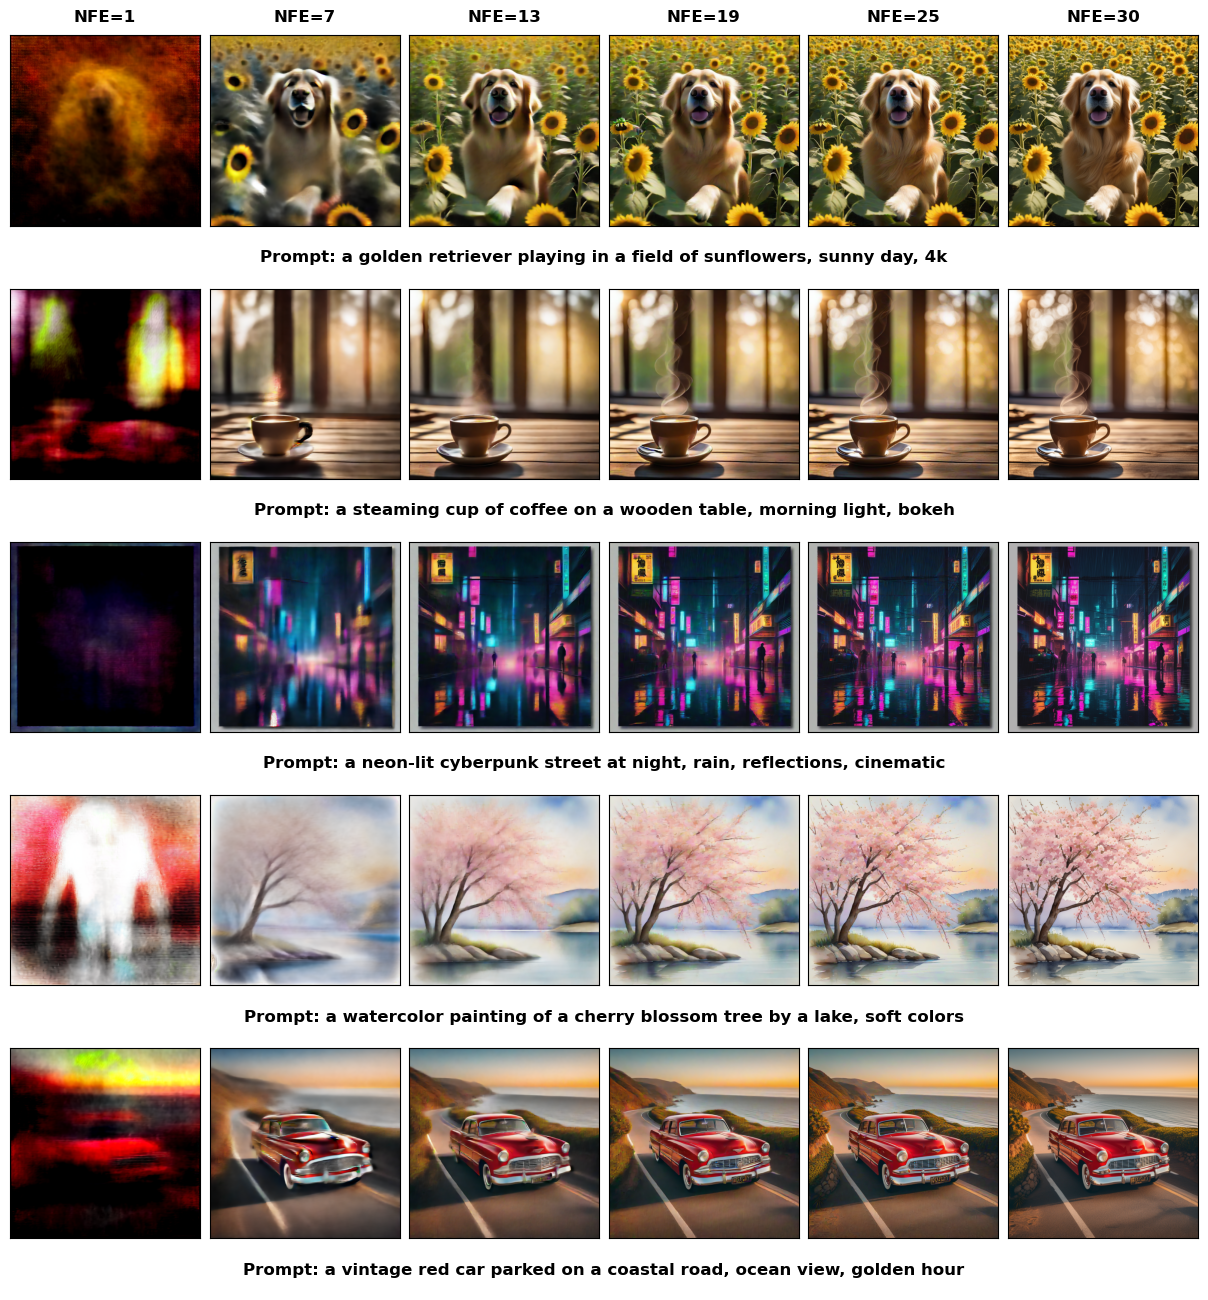

Saved to figs/x0_visual_comparison.pdf and .png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

n_prompts = len(PROMPTS)
n_steps = len(CAPTURE_STEPS)

# 核心逻辑：每 1 个提示词占用 2 行：第 1 行是图像序列，第 2 行是纯文字标签
# 总行数为 n_prompts * 2
fig = plt.figure(figsize=(n_steps * 2.2, n_prompts * 2.8))
gs = gridspec.GridSpec(n_prompts * 2, n_steps, figure=fig, 
                       height_ratios=[1, 0.2] * n_prompts, # 图像高，文字区矮
                       hspace=0.05, wspace=0.05, 
                       bottom=0.05, top=0.95, left=0.05, right=0.95)

for ri, prompt in enumerate(PROMPTS):
    images = all_x0[prompt]
    
    # 1. 绘制图像序列 (占据每一组的第 0 行)
    for ci in range(n_steps):
        ax = plt.subplot(gs[ri * 2, ci])
        ax.imshow(images[ci])
        ax.set_xticks([])
        ax.set_yticks([])
        
        # 顶部 NFE 标识
        if ri == 0:
            k = CAPTURE_STEPS[ci]
            ax.set_title(f"NFE={k+1}", fontsize=12, fontweight='bold', pad=10)
            
    # 2. 绘制提示词 (占据每一组的第 1 行)
    # 跨越所有列 (colspan=n_steps)
    ax_text = plt.subplot(gs[ri * 2 + 1, :])
    ax_text.text(0.5, 0.5, f"Prompt: {prompt}", 
                 fontsize=12, fontweight='bold', 
                 ha='center', va='center')
    ax_text.axis('off') # 隐藏坐标轴

plt.show()
#fig.savefig("figs/x0_visual_comparison.pdf", dpi=300, bbox_inches="tight", pad_inches=0.05)
#fig.savefig("figs/x0_visual_comparison.png", dpi=200, bbox_inches="tight", pad_inches=0.05)
print("Saved to figs/x0_visual_comparison.pdf and .png")